In [40]:
import csv
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import seaborn as sns

In [51]:
curr_dir = os.getcwd()
all_dirs = os.listdir(curr_dir)
exp_dirs = [d for d in all_dirs if os.path.isdir(d)]
csv_files = [f'{d}/csv_logs/meltingpot_predator_prey__open.csv' for d in exp_dirs]
exp_names = [exp_dir.replace('pred', 'pdt') for exp_dir in exp_dirs]
assert len(exp_dirs) == len(csv_files)

In [50]:
def get_mean_rewards(csv_file, n_agents):
    agent_idx_to_mean_reward = {}
    with open(csv_file, 'r') as f:
        reader = csv.DictReader(f)
        rows = list(reader)
        for agent_idx in range(n_agents):
            try:
                mean_reward = np.mean([float(row[f'agent_{agent_idx}/episode_return']) for row in rows])
            except Exception as e:
                print(f"Error processing agent_{agent_idx} in file {csv_file}: {e}")
            agent_idx_to_mean_reward[agent_idx] = mean_reward
    return agent_idx_to_mean_reward

In [52]:
N_AGENTS = 4
exp_name_to_agent_rewards = {}
for exp_name, csv_file in zip(exp_names, csv_files):
    exp_name_to_agent_rewards[exp_name] = get_mean_rewards(csv_file, n_agents=N_AGENTS)

In [47]:
def plot_cross_play_heatmaps(result_dict):
    p1_data = []
    p2_data = []
    
    # Parse the dictionary
    for key, rewards in result_dict.items():
        party1_config, party2_config = key.split('__')
        
        # Extract Party 1 (Index 0)
        p1_data.append({
            'Party 1 Config': party1_config,
            'Party 2 Config': party2_config,
            'Reward': rewards[0]
        })
        
        # Extract Party 2 (Indices 1, 2, 3)
        for agent_idx in [1, 2, 3]:
            col_name = f"{party2_config}\n(Agent {agent_idx})"
            p2_data.append({
                'Party 1 Config': party1_config,
                'Party 2 Config + Agent': col_name,
                'Reward': rewards[agent_idx]
            })
            
    # Heatmap 1: First Party Performance
    df_p1 = pd.DataFrame(p1_data)
    pivot_p1 = df_p1.pivot(index='Party 1 Config', columns='Party 2 Config', values='Reward')
    pivot_p1.sort_index(inplace=True)
    pivot_p1.sort_index(axis=1, inplace=True)
    
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot_p1, annot=True, cmap="Reds", fmt=".2f", linewidths=.5, ax=ax1)
    ax1.set_title('Predator Rewards', pad=20, fontsize=14)
    ax1.set_xlabel('Prey Config', fontsize=12)
    ax1.set_ylabel('Predator Config', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    fig1.tight_layout()
    plt.show()
    
    # Heatmap 2: Second Party (Agents) Performance    
    df_p2 = pd.DataFrame(p2_data)
    pivot_p2 = df_p2.pivot(index='Party 1 Config', columns='Party 2 Config + Agent', values='Reward')
    
    def col_sort_key(col):
        config, agent = col.split('\n')
        ag_idx = int(agent.split(' ')[-1][:-1]) 
        return (config, ag_idx)
        
    sorted_cols = sorted(pivot_p2.columns, key=col_sort_key)
    pivot_p2 = pivot_p2[sorted_cols]
    pivot_p2.sort_index(inplace=True)
    
    fig2, ax2 = plt.subplots(figsize=(16, 6))
    sns.heatmap(pivot_p2, annot=True, cmap="Blues", fmt=".2f", linewidths=.5, ax=ax2)
       
    # Draw rectangles to highlight groups of 3 agents belonging to the same config.
    num_rows = len(pivot_p2.index)
    num_cols = len(pivot_p2.columns)
    
    # We step by 3 because we know there are exactly 3 agents per prey config group.
    for i in range(0, num_cols, 3):
        # x-coordinate starts at 'i', y-coordinate starts at 0 (top of the map)
        # width is 3 columns, height spans all rows
        rect = patches.Rectangle(
            (i, 0), 3, num_rows, 
            linewidth=4, 
            edgecolor='black', 
            facecolor='none', 
            linestyle='-'
        )
        ax2.add_patch(rect)
    
    ax2.set_title('Prey Rewards', pad=20, fontsize=14)
    ax2.set_xlabel('Prey Config', fontsize=12)
    ax2.set_ylabel('Predator Config', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    fig2.tight_layout()
    plt.show()

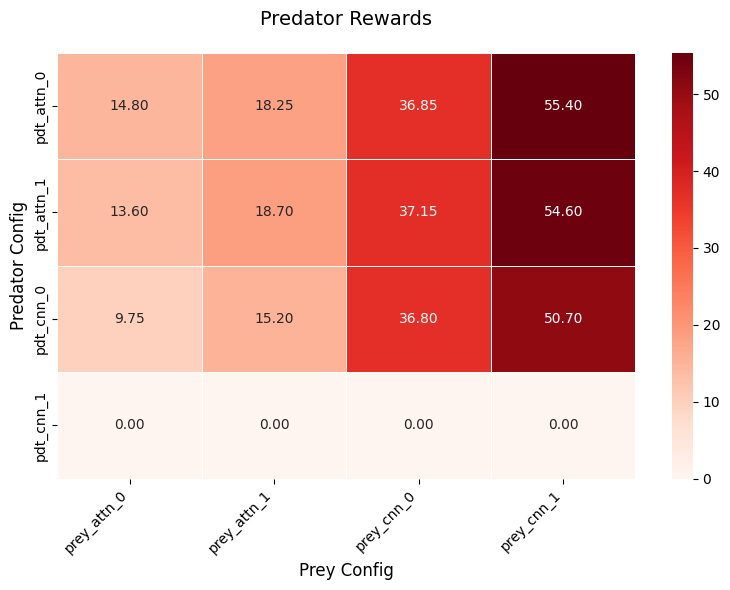

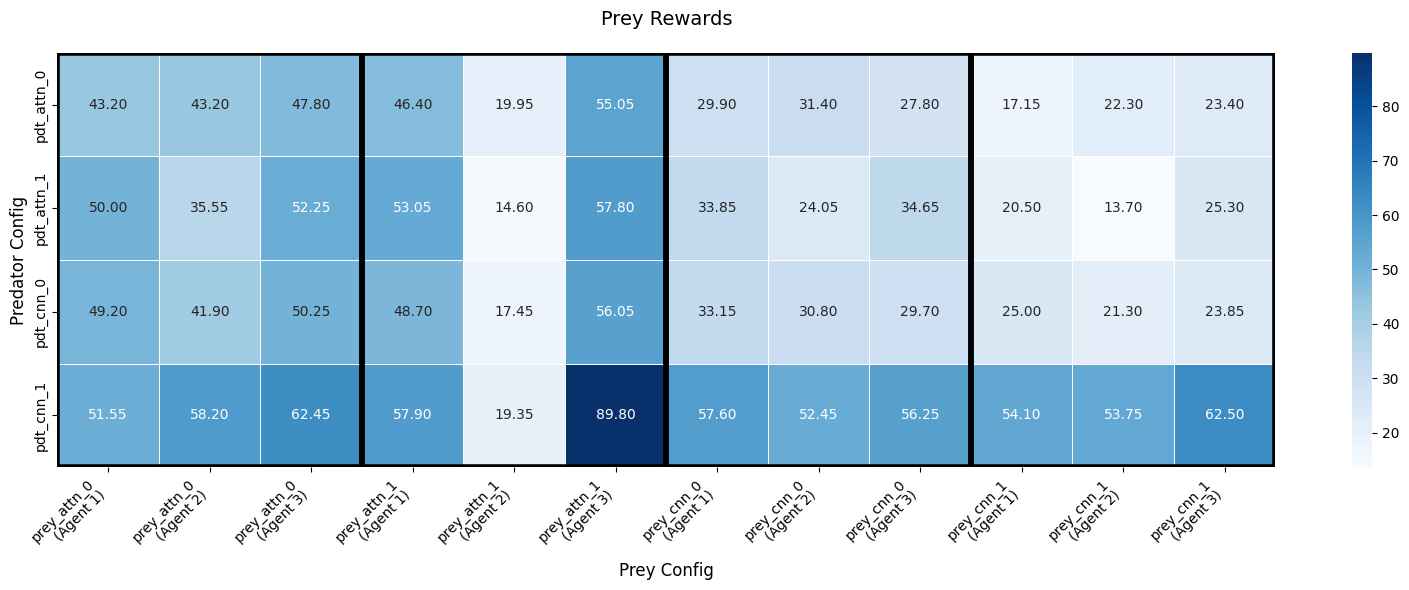

In [53]:
plot_cross_play_heatmaps(exp_name_to_agent_rewards)